주문당 평균 상품 수: 10.09개
전체 재구매율: 58.97%


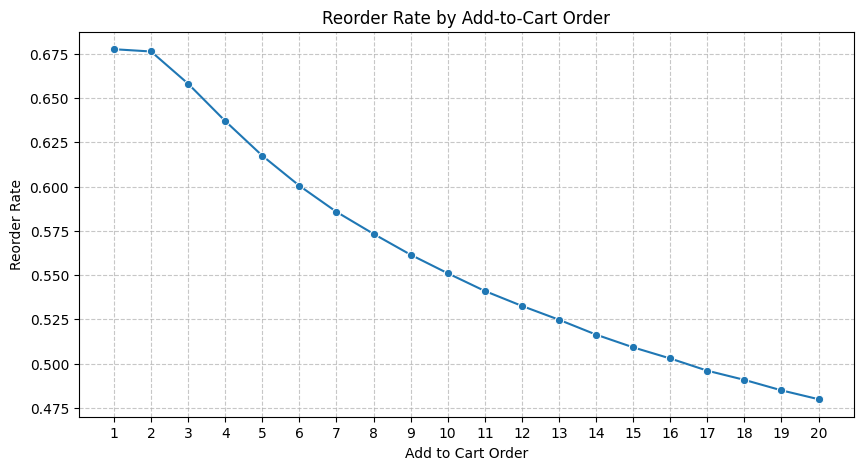

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
train = pd.read_csv('../data/order_products__prior.csv')

# 2. 주문당 평균 상품 수 계산
avg_order_size = train.groupby('order_id')['product_id'].count().mean()
print(f"주문당 평균 상품 수: {avg_order_size:.2f}개")

# 3. 전체 재구매율 계산
total_reorder_rate = train['reordered'].mean()
print(f"전체 재구매율: {total_reorder_rate:.2%}")

# 4. 장바구니 순서와 재구매 상관관계 분석 (상위 20개)
order_reorder_relation = train.groupby('add_to_cart_order')['reordered'].mean().head(20)

# 5. 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(x=order_reorder_relation.index, y=order_reorder_relation.values, marker='o')
plt.title('Reorder Rate by Add-to-Cart Order')
plt.xlabel('Add to Cart Order')
plt.ylabel('Reorder Rate')
plt.xticks(range(1, 21))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()